# 🚀 Practice Day 02

**📅 Date:** 2026-09-13  
**📁 Category:** Phase 1 · NumPy 기초 (Round 1/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Practice vectorized NumPy array operations — no explicit Python loops (순수 배열 연산으로, 반복문 없이 계산)
- Combine multiple arrays into a derived business metric (여러 배열을 조합해 파생 지표 계산)
- Use boolean masking to filter and summarize data (불리언 마스킹으로 필터링·요약)

---
# 📂 Dataset

**Dataset Name:** Delivery Rider Settlement Data (배달 라이더 정산 데이터)

**Source:** Synthetically generated for practice, fixed random seed (연습용으로 코드에서 직접 생성, seed 고정)

**Description:** 270 deliveries with distance, time, delivery type, weather condition, base fee, and weather bonus. The numeric columns are also kept as plain NumPy arrays (`distance_km`, `delivery_time_min`, `base_fee`, `weather_bonus`) so you can practice raw array operations directly, not only through pandas.
(배달 270건 — 거리, 소요시간, 배달 유형, 날씨, 기본요금, 날씨 보너스 포함. distance_km / delivery_time_min / base_fee / weather_bonus는 순수 NumPy 배열로도 그대로 남아있어서 pandas 없이 배열 연산만으로 연습 가능합니다)

## Dataset Preview

In [60]:
# Dataset Preview
import pandas as pd
import numpy as np

np.random.seed(42)

n_deliveries = 270

delivery_id = np.array([f'DLV-{i+1:05d}' for i in range(n_deliveries)])

distance_km = np.round(np.random.uniform(0.5, 12.0, n_deliveries), 1)

# delivery time roughly follows distance (~3 min/km) plus prep/wait noise
delivery_time_min = np.round(distance_km * 3 + np.random.normal(8, 3, n_deliveries)).astype(int)
delivery_time_min = np.clip(delivery_time_min, 5, None)

delivery_type = np.random.choice(['Regular', 'Express'], size=n_deliveries, p=[0.7, 0.3])
base_fee = np.where(delivery_type == 'Express', 4500, 3000)

weather = np.random.choice(['Clear', 'Rain', 'Snow'], size=n_deliveries, p=[0.70, 0.22, 0.08])
weather_bonus = np.select(
    [weather == 'Snow', weather == 'Rain'],
    [2000, 1000],
    default=0
)

# distance_km / delivery_time_min / base_fee / weather_bonus stay available as plain
# NumPy arrays below (not just inside df) - use them directly in the Analysis section.
df = pd.DataFrame({
    'delivery_id': delivery_id,
    'distance_km': distance_km,
    'delivery_time_min': delivery_time_min,
    'delivery_type': delivery_type,
    'weather': weather,
    'base_fee': base_fee,
    'weather_bonus': weather_bonus,
})

df.head()

,delivery_id,distance_km,delivery_time_min,delivery_type,weather,base_fee,weather_bonus
0,DLV-00001,4.8,24,Regular,Clear,3000,0
1,DLV-00002,11.4,44,Regular,Clear,3000,0
2,DLV-00003,8.9,36,Express,Clear,4500,0
3,DLV-00004,7.4,42,Express,Clear,4500,0
4,DLV-00005,2.3,17,Regular,Clear,3000,0


## Dataset Information

In [61]:
# Dataset Information
print(df.shape)
df.info()
df.describe()

(270, 7)
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   delivery_id        270 non-null    str    
 1   distance_km        270 non-null    float64
 2   delivery_time_min  270 non-null    int64  
 3   delivery_type      270 non-null    str    
 4   weather            270 non-null    str    
 5   base_fee           270 non-null    int64  
 6   weather_bonus      270 non-null    int64  
dtypes: float64(1), int64(3), str(3)
memory usage: 14.9 KB


,distance_km,delivery_time_min,base_fee,weather_bonus
count,270.000000,270.000000,270.00000,270.000000
mean,6.182593,26.674074,3400.00000,403.703704
std,3.398725,10.673477,664.55676,636.545908
min,0.600000,5.000000,3000.00000,0.000000
25%,3.225000,17.000000,3000.00000,0.000000
50%,6.350000,26.000000,3000.00000,0.000000
75%,9.075000,36.750000,4500.00000,1000.000000
max,11.900000,47.000000,4500.00000,2000.000000


---
# ❓ Business Questions

1. What is the total settlement pay for each delivery — base fee + distance fee (500 KRW/km) + weather bonus? (기본요금 + 거리요금(km당 500원) + 날씨 보너스를 더한 배달건별 총 정산액은?)
2. How many deliveries covered more than 8 km, and what percentage of all deliveries is that? (8km 넘게 이동한 배달은 몇 건이며 전체의 몇 %인가?)
3. What are the mean, median, and standard deviation of total settlement pay? (총 정산액의 평균/중앙값/표준편차는?)
4. What does the distribution of total settlement pay look like? (총 정산액의 분포는 어떤 모습인가?)
5. How does average settlement pay differ by weather condition? (날씨별 평균 정산액은 어떻게 다른가?)

---
# 🛠 Skills Used
- [x] Python
- [x] NumPy — vectorized `total_pay` from arrays (`distance_km * 500 + base_fee + weather_bonus`); boolean mask for long trips  
  (배열 연산으로 정산액 계산, 불리언 마스크로 장거리 건수)
- [x] Pandas — `mean` / `median` / `std`, weather `groupby` for Chart 2  
  (평균·중앙값·표준편차, 날씨별 평균)
- [ ] SQL
- [x] Matplotlib — histogram of `total_pay`, bar chart of average pay by weather  
  (정산액 히스토그램, 날씨별 평균 막대)
- [ ] Other:

---
# 🧹 Data Cleaning

Things I cleaned / checked:  
(확인·처리한 항목)

- [x] Missing Values — 0 missing cells across all columns  
  (결측값 없음)
- [x] Duplicate Rows — 0 duplicate rows  
  (중복 행 없음)
- [x] Wrong Data Types — `distance_km` is float; time / fees are integers; type and weather are strings  
  (`distance_km`는 실수, 시간·요금은 정수, 유형·날씨는 문자열)
- [ ] Rename Columns — not needed  
  (컬럼명 변경 불필요)
- [ ] Drop Columns — not needed  
  (컬럼 삭제 불필요)

Note: `total_pay` is a derived metric for analysis, not a cleaning step.  
(참고: `total_pay`는 클리닝이 아니라 분석용 파생 지표)

In [62]:
# Data Cleaning

print(df.isnull().sum())
print(df.duplicated().sum())
print(df.dtypes)

delivery_id          0
distance_km          0
delivery_time_min    0
delivery_type        0
weather              0
base_fee             0
weather_bonus        0
dtype: int64
0
delivery_id              str
distance_km          float64
delivery_time_min      int64
delivery_type            str
weather                  str
base_fee               int64
weather_bonus          int64
dtype: object


---
# 📊 Analysis

## Question 1

**Question:** What is the total settlement pay for each delivery — base fee + distance fee (500 KRW/km) + weather bonus? (기본요금 + 거리요금(km당 500원) + 날씨 보너스를 더한 배달건별 총 정산액은?)

**Result:** Created `total_pay` for 270 deliveries. Company total **1,861,650 KRW**. Per delivery min **3,300** / max **11,950**.  
(270건 `total_pay` 생성. 총지급 1,861,650원. 건당 최소 3,300원, 최대 11,950원)

**Insight:** This column is the number later questions and charts use. Without it you cannot rank deliveries or plot pay.  
(이 컬럼이 이후 질문과 차트의 기준 숫자. 없으면 정산액을 비교하거나 그릴 수 없음)


In [63]:
# Question 1: total_pay = base_fee + distance_km * 500 + weather_bonus (per delivery)
# (배달건별 총 정산액 = 기본요금 + 거리(km) x 500원 + 날씨 보너스)
# Tip: use the raw NumPy arrays (distance_km, base_fee, weather_bonus) or df['col'].to_numpy()

X = df[['distance_km', 'base_fee', 'weather_bonus']].to_numpy()
df['total_pay'] = X[:, 0] * 500 + X[:, 1] + X[:, 2]
display(df.head())

print('n:', len(df))
print('total payout:', df['total_pay'].sum())
print('min / max:', df['total_pay'].min(), '/', df['total_pay'].max())


,delivery_id,distance_km,delivery_time_min,delivery_type,weather,base_fee,weather_bonus,total_pay
0,DLV-00001,4.8,24,Regular,Clear,3000,0,5400.0
1,DLV-00002,11.4,44,Regular,Clear,3000,0,8700.0
2,DLV-00003,8.9,36,Express,Clear,4500,0,8950.0
3,DLV-00004,7.4,42,Express,Clear,4500,0,8200.0
4,DLV-00005,2.3,17,Regular,Clear,3000,0,4150.0


n: 270
total payout: 1861650.0
min / max: 3300.0 / 11950.0


## Question 2

**Question:** How many deliveries covered more than 8 km, and what percentage of all deliveries is that? (8km 넘게 이동한 배달은 몇 건이며 전체의 몇 %인가?)

**Result:** **92 deliveries (34.07% of 270)**.  
(92건, 전체 270건의 34.07%)

**Insight:** About one in three trips is a long delivery. That is a large enough share to matter for operations, not a rare edge case.  
(대략 세 건 중 한 건이 장거리. 드문 예외가 아니라 운영에서 볼 만한 비중)


In [64]:
# Question 2: Count deliveries with distance_km > 8, and their share of all deliveries
# (거리가 8km를 초과하는 배달 건수와 전체 대비 비율)

mask = df['distance_km'] > 8
print(f'over 8km count: {int(mask.sum())}')
print(f'over 8km share: {mask.mean():.2%}')


over 8km count: 92
over 8km share: 34.07%


## Question 3

**Question:** What are the mean, median, and standard deviation of total settlement pay? (총 정산액의 평균/중앙값/표준편차는?)

**Result:** Mean **6,895 KRW**, median **6,800 KRW**, std **2,035 KRW**.  
(평균 6,895원, 중앙값 6,800원, 표준편차 2,035원)

**Insight:** Mean and median are close, so the typical pay is not pulled far to one side. Std (~2,000) is how far a usual delivery sits from the mean — not an outlier flag.  
(평균과 중앙값이 비슷해서 한쪽으로 크게 치우치지는 않음. 표준편차 약 2,000원은 보통 값이 평균에서 얼마나 떨어지나이지, 이상치 신호가 아님)


In [65]:
# Question 3: Compute mean, median, and standard deviation of total settlement pay
# (총 정산액의 평균, 중앙값, 표준편차 계산)

print(f'mean: {df["total_pay"].mean():.2f}')
print(f'median: {df["total_pay"].median():.2f}')
print(f'std: {df["total_pay"].std():.2f}')


mean: 6895.00
median: 6800.00
std: 2035.06


---
# 📈 Visualization

**Chart 1:** Distribution of total settlement pay (histogram) — 총 정산액 분포

*Interpretation:* Most deliveries sit in the middle of the pay range, with two taller groups rather than one single peak.  
(대부분의 정산액이 중간대에 있고, 봉우리가 하나보다 두 쪽에 더 쌓여 보임)

---

**Chart 2:** Average settlement pay by weather condition (bar chart) — 날씨별 평균 정산액

*Interpretation:* Average pay is highest on snow days, then rain, then clear.  
(평균 정산액은 눈 > 비 > 맑음)


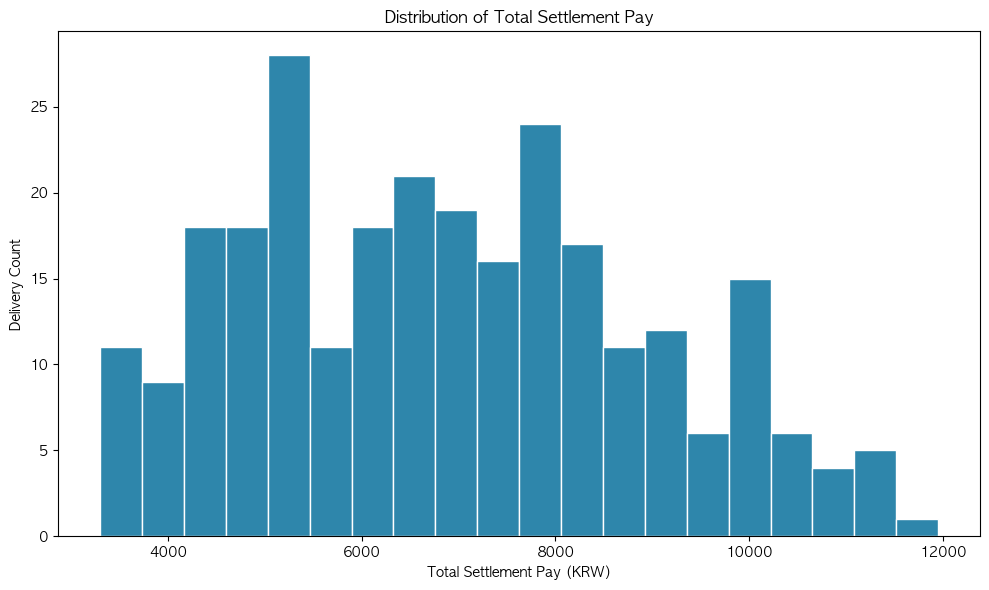

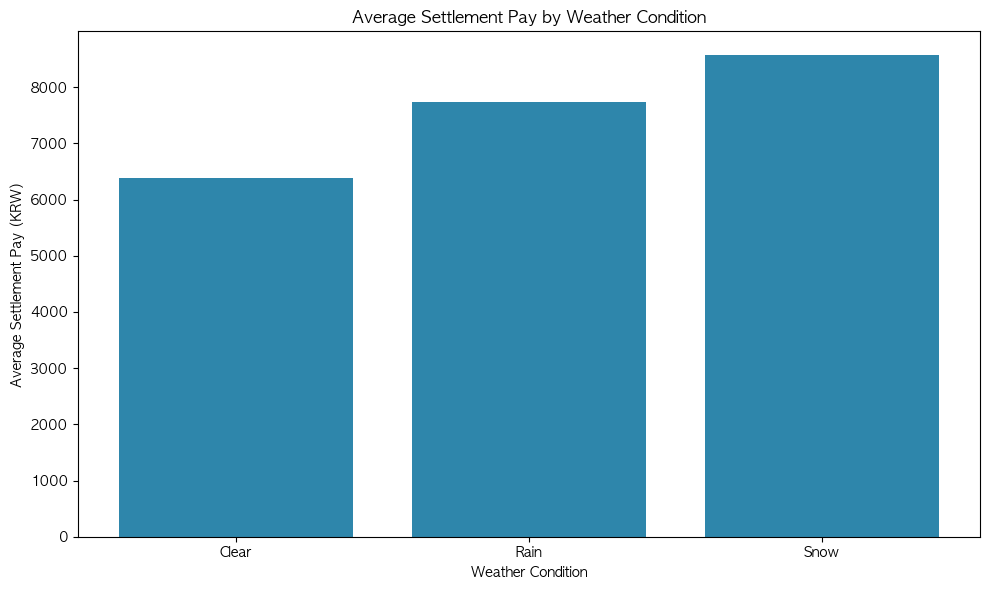

In [66]:
# Visualization
import matplotlib.pyplot as plt
# import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'   # macOS: 'AppleGothic', Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Chart 1: Distribution of total settlement pay (histogram)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['total_pay'], bins=20, color='#2E86AB', edgecolor='white')
ax.set_title('Distribution of Total Settlement Pay')
ax.set_xlabel('Total Settlement Pay (KRW)')
ax.set_ylabel('Delivery Count')
plt.tight_layout()
plt.show()

# Chart 2: Average settlement pay by weather condition (bar chart)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df['weather'].unique(), df.groupby('weather')['total_pay'].mean(), color='#2E86AB')
ax.set_title('Average Settlement Pay by Weather Condition')
ax.set_xlabel('Weather Condition')
ax.set_ylabel('Average Settlement Pay (KRW)')
plt.tight_layout()
plt.show()


---
# 💼 Business Insights
*What did I discover?*

- Total payout for 270 deliveries is 1,861,650 KRW; a typical delivery is about 6,800–6,900 KRW.  
  (270건 총지급 1,861,650원. 보통 한 건은 약 6,800~6,900원)
- Long trips (>8 km) are 92 cases, 34% of all deliveries.  
  (8km 초과 배달은 92건, 전체의 34%)
- Average pay is higher on snow/rain days than on clear days.  
  (평균 정산액은 맑은 날보다 눈·비 오는 날이 더 높음)


---
# 🎯 Business Recommendation
*If I were the Business Analyst...*

1. Track long-distance share (~34%) as an ops metric, not only total payout.  
   (총지급만 보지 말고 장거리 비중 약 34%도 운영 지표로 보기)
2. Treat weather as a pay driver in the fee formula, especially snow vs clear.  
   (요금 공식에서 날씨를 정산 차이 요인으로 보기. 특히 눈 vs 맑음)
3. Next: check whether the two histogram peaks match Regular vs Express.  
   (다음: 히스토그램 봉우리 두 개가 Regular vs Express인지 확인)


---
# ❌ Mistakes
*What mistakes did I make today?*

- Q2 printed the share (34.07%) but not the count the question asked for (92).  
  (Q2에서 비율만 출력하고, 질문이 요구한 건수 92를 안 찍음)
- Treated Q1 as “just a calculation,” so no insight seemed possible until the column was reused in later questions.  
  (Q1을 단순 계산으로만 봐서, 그 컬럼을 나중에 써야 인사이트가 나온다는 점을 놓침)
- Read mean ≈ median as “no outliers,” and treated std as an outlier flag instead of typical spread.  
  (평균≈중앙값을 이상치 없음으로 읽고, 표준편차를 이상치 신호로 오해)

---
# ✅ What I Learned
*Today's biggest lesson*

- A derived column (`total_pay`) is what later questions and charts use.  
  (파생 컬럼 `total_pay`가 이후 질문과 차트의 기준)
- For a cutoff question, print both count and %.  
  (컷 질문은 건수와 비율을 같이 출력)
- Mean ≈ median means little skew; std is typical spread around the mean.  
  (평균≈중앙값은 치우침이 작다는 뜻. 표준편차는 평균 주변의 보통 퍼짐)


---
# 🧠 Reflection

**What was difficult?**  
Turning printed numbers into Result / Insight, and knowing how far to go past the question.  
(출력된 숫자를 Result·Insight로 쓰는 것, 질문보다 어디까지 더 파야 하는지)

**Why?**  
The code already answered the question, so extra tables felt necessary — but they were a later step.  
(코드가 이미 답을 찍어서, 표를 더 만들어야 할 것 같았음. 그건 다음 단계)

**How did I solve it?**  
Wrote Result from the question output only (sum / count / mean-median-std, and what the two charts show).  
(질문이 물은 출력만으로 Result를 씀 — 합계·건수·평균·중앙값·표준편차, 차트 두 개가 보이는 것)

**What would I do differently next time?**  
Answer the written question first. Keep extra cuts for later.  
(적힌 질문을 먼저 답하고, 추가 쪼개기는 나중에)


---
# ⭐ Self Evaluation

**Understanding**  
⭐⭐⭐⭐⭐⭐☆☆☆☆  
Vectorized pay and masking are clear; std vs outliers and mixture histograms are still new.  
(배열로 정산액 만들고 마스크 거는 건 이해됨. 표준편차 vs 이상치, 혼합분포 히스토그램은 아직 새로움)

**Confidence**  
⭐⭐⭐⭐⭐☆☆☆☆☆  
Can compute the metrics; less sure about turning a threshold or a two-peak chart into a stakeholder sentence.  
(지표 계산은 가능. 컷이나 두 봉우리 차트를 이해관계자 문장으로 바꾸는 건 아직 덜 확실)

**Difficulty**  
⭐⭐⭐⭐⭐⭐☆☆☆☆  
NumPy syntax was manageable; the hard part was “why this question,” not the code.  
(NumPy 문법 난이도는 괜찮았고, 어려운 부분은 코드가 아니라 “왜 이 질문인가”)